In [ ]:
!chmod 600 /root/.config/kaggle/kaggle.json
!kaggle datasets list


In [ ]:
pwd


In [ ]:
import os
import zipfile
import pandas as pd

# Ensure the Kaggle API is set up correctly
# Use the Kaggle API to download the Titanic dataset
os.environ['KAGGLE_CONFIG_DIR'] = "/allah/stuff/ml/kaggle"
os.chdir('/allah/data/')
print(os.getcwd())
!kaggle competitions download -c titanic
# Extract the downloaded zip file
with zipfile.ZipFile("titanic.zip", "r") as zip_ref:
    zip_ref.extractall("titanic_data")

# Load the dataset into a pandas DataFrame
train_df = pd.read_csv("titanic_data/train.csv")
test_df = pd.read_csv("titanic_data/test.csv")

# Display the first few rows of the training dataset
print(train_df.head())


In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv("titanic_data/train.csv")  # Adjust the path if necessary

# Display the first few rows of the dataset
print(df.head())


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)  # Fill missing Age values with median
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)  # Fill missing Embarked values with mode

# Encode categorical variables
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])  # Encode Sex (male=1, female=0)
df['Embarked'] = label_encoder.fit_transform(df['Embarked'])  # Encode Embarked (C=0, Q=1, S=2)

# Select features and target variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [37]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 200, 500, 1000],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
                           param_grid=param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=1)

# Fit the model
grid_search.fit(X_train, y_train)

# Print the best parameters
print(f"Best Parameters: {grid_search.best_params_}")

# Convert results to a DataFrame for better readability
results = pd.DataFrame(grid_search.cv_results_)

# Display relevant columns (mean accuracy and parameter combinations)
results_display = results[['mean_test_score', 'std_test_score', 'params']]
print("Grid Search Results:")
print(results_display)

# Optionally, sort by accuracy
sorted_results = results_display.sort_values(by='mean_test_score', ascending=False)
print("Sorted Results by Accuracy:")
print(sorted_results)


Fitting 5 folds for each of 45 candidates, totalling 225 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}
Grid Search Results:
    mean_test_score  std_test_score  \
0          0.806166        0.014584   
1          0.823008        0.023468   
2          0.824407        0.016351   
3          0.828602        0.016874   
4          0.831419        0.013821   
5          0.804738        0.019388   
6          0.811760        0.020854   
7          0.825805        0.014041   
8          0.822998        0.010884   
9          0.818832        0.009051   
10         0.806126        0.021113   
11         0.811770        0.019844   
12         0.816005        0.009382   
13         0.820240        0.012754   
14         0.820270        0.018663   
15         0.834236        0.014150   
16         0.832847        0.008536   
17         0.817423        0.013215   
18         0.807614        0.011752   
19         0.801999        0.013105   
20         0.825805   

In [38]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Create an XGBoost classifier
model = xgb.XGBClassifier(
    max_depth=3,
    learning_rate=0.2,
    n_estimators=50,
    use_label_encoder=False,
    eval_metric='logloss'  # Required to avoid warnings
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
# Classification report
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)



Accuracy: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.90      0.85       105
           1       0.83      0.72      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [34]:
# training data classicication report
from sklearn.metrics import classification_report
y_pred_train = model.predict(X_train)
report = classification_report(y_train, y_pred_train)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.92       444
           1       0.93      0.76      0.84       268

    accuracy                           0.89       712
   macro avg       0.90      0.86      0.88       712
weighted avg       0.89      0.89      0.89       712



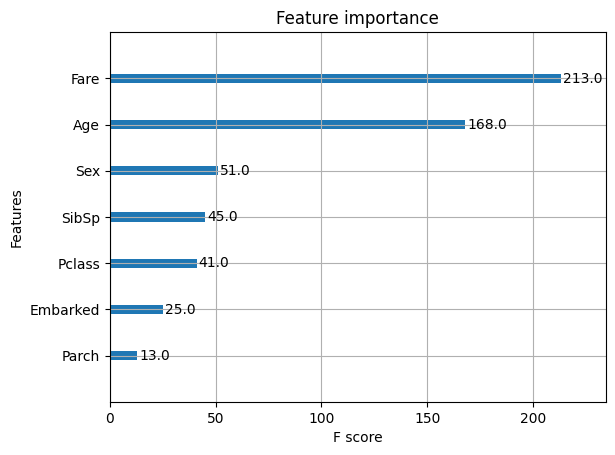

In [24]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()
